In [1]:
!pip install nilearn nibabel matplotlib seaborn pandas -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 63.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from nilearn import datasets
from nilearn.maskers import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure

In [3]:
dataset = datasets.fetch_development_fmri(n_subjects=30)
func_file = dataset.func[0]

print("Using subject scan:")
print(func_file)

[fetch_development_fmri] Added README.md to /root/nilearn_data

[fetch_development_fmri] Dataset created in /root/nilearn_data/development_fmri

[fetch_development_fmri] Added README.md to /root/nilearn_data/development_fmri

[fetch_development_fmri] Dataset created in /root/nilearn_data/development_fmri/development_fmri

[fetch_development_fmri] Downloading data from https://osf.io/yr3av/download ...

...

[fetch_development_fmri] Downloading data from https://osf.io/download/5c8ff38c4712b4001a3b5573/ ...

[fetch_development_fmri]  ...done. (1 seconds, 0 min)

[fetch_development_fmri] Downloading data from https://osf.io/download/5c8ff38da743a900176080a2/ ...

[fetch_development_fmri]  ...done. (2 seconds, 0 min)

Using subject scan:
/root/nilearn_data/development_fmri/development_fmri/sub-pixar128_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz


In [4]:
atlas = datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")

atlas_img = atlas.maps
labels = atlas.labels

print("Number of labels:", len(labels))
print(labels[:10])

[fetch_atlas_harvard_oxford] Dataset created in /root/nilearn_data/fsl

[fetch_atlas_harvard_oxford] Downloading data from https://www.nitrc.org/frs/download.php/9902/HarvardOxford.tgz 
...

[fetch_atlas_harvard_oxford]  ...done. (1 seconds, 0 min)

[fetch_atlas_harvard_oxford] Extracting data from 
/root/nilearn_data/fsl/5c734f16e50cc772ef593cab9bb3137b/HarvardOxford.tgz...

[fetch_atlas_harvard_oxford] .. done.

Number of labels: 49
['Background', 'Frontal Pole', 'Insular Cortex', 'Superior Frontal Gyrus', 'Middle Frontal Gyrus', 'Inferior Frontal Gyrus, pars triangularis', 'Inferior Frontal Gyrus, pars opercularis', 'Precentral Gyrus', 'Temporal Pole', 'Superior Temporal Gyrus, anterior division']


In [5]:
masker = NiftiLabelsMasker(
    labels_img=atlas_img,
    standardize=True,
    detrend=True,
    low_pass=0.1,
    high_pass=0.01,
    t_r=2.0
)

time_series = masker.fit_transform(func_file)

print("Time series shape:", time_series.shape)

/tmp/ipykernel_549/2887767487.py:10: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  time_series = masker.fit_transform(func_file)


Time series shape: (168, 48)


In [6]:
masker = NiftiLabelsMasker(
    labels_img=atlas_img,
    standardize="zscore_sample",
    detrend=True,
    low_pass=0.1,
    high_pass=0.01,
    t_r=2.0
)

In [7]:
correlation_measure = ConnectivityMeasure(kind="correlation")
connectivity_matrix = correlation_measure.fit_transform([time_series])[0]

print(connectivity_matrix.shape)

(48, 48)


/tmp/ipykernel_549/3045009788.py:2: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  connectivity_matrix = correlation_measure.fit_transform([time_series])[0]


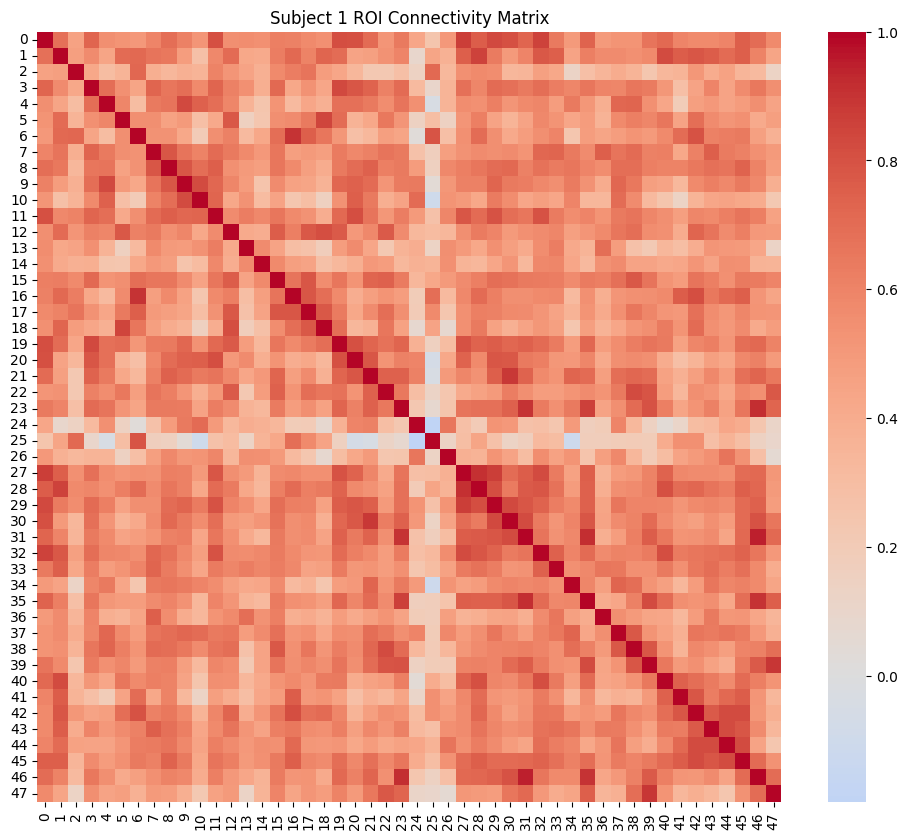

In [8]:
plt.figure(figsize=(12,10))
sns.heatmap(connectivity_matrix, cmap="coolwarm", center=0)
plt.title("Subject 1 ROI Connectivity Matrix")
plt.show()

In [9]:
correlation_measure = ConnectivityMeasure(
    kind="correlation",
    standardize="zscore_sample"
)

connectivity_matrix = correlation_measure.fit_transform([time_series])[0]